# Nigerian Drug Safety News Intelligence Using NLP

## Capstone Project

### Project Overview

This project applies Natural Language Processing (NLP) techniques to analyze Nigerian drug safety news articles.

The objective is to identify major themes, detect hidden patterns, and understand public health concerns related to counterfeit medicines, medicine safety, regulatory actions, and pharmacovigilance.

### Dataset

- Number of articles analyzed: 30
- Sources include NAFDAC, Premium Times, Punch, and Federal Ministry of Health Nigeria
- Data fields:
  - Title
  - Source
  - Date
  - Article Text
  - URL
  - Topic Category

### Methods Used

- Data Cleaning
- Exploratory Data Analysis
- Text Preprocessing
- TF-IDF Feature Extraction
- Latent Dirichlet Allocation (LDA) Topic Modelling
- Text Visualization

In [ ]:
import pandas as pd
df = pd.read_csv("../data/raw/NDSNC_raw_articles.csv")

df.head()

,title,source,date,text,url,topic_keyword
0,NAFDAC warns against counterfeit medicines,NAFDAC,2026,NAFDAC continues efforts to protect Nigerians ...,https://nafdac.gov.ng,counterfeit drugs
1,Experts discuss medication safety in Nigeria,Health Report,2026,Healthcare professionals emphasize responsible...,NaN,drug safety
2,NAFDAC warns Nigerians against counterfeit med...,NAFDAC,2026,NAFDAC continues efforts to protect Nigerians ...,https://nafdac.gov.ng,counterfeit drugs
3,NAFDAC strengthens medicine safety monitoring,NAFDAC,2026,"The agency improves medicine regulation, monit...",https://nafdac.gov.ng,drug safety
4,Experts warn Nigerians against self-medication,Channels TV,2026,Health professionals warn that self-medication...,https://www.channelstv.com,self medication


In [2]:
df.shape

(7, 6)

In [3]:
df[['title', 'source']].head(10)

,title,source
0,NAFDAC warns against counterfeit medicines,NAFDAC
1,Experts discuss medication safety in Nigeria,Health Report
2,NAFDAC warns Nigerians against counterfeit med...,NAFDAC
3,NAFDAC strengthens medicine safety monitoring,NAFDAC
4,Experts warn Nigerians against self-medication,Channels TV
5,Health experts raise concerns over antibiotic ...,Channels TV
6,Nigeria continues campaign on medicine safety ...,Channels TV


In [4]:
df.tail()

,title,source,date,text,url,topic_keyword
2,NAFDAC warns Nigerians against counterfeit med...,NAFDAC,2026,NAFDAC continues efforts to protect Nigerians ...,https://nafdac.gov.ng,counterfeit drugs
3,NAFDAC strengthens medicine safety monitoring,NAFDAC,2026,"The agency improves medicine regulation, monit...",https://nafdac.gov.ng,drug safety
4,Experts warn Nigerians against self-medication,Channels TV,2026,Health professionals warn that self-medication...,https://www.channelstv.com,self medication
5,Health experts raise concerns over antibiotic ...,Channels TV,2026,Medical experts encourage responsible antibiot...,https://www.channelstv.com,antibiotic resistance
6,Nigeria continues campaign on medicine safety ...,Channels TV,2026,Public health campaigns emphasize safe medicat...,https://www.channelstv.com,drug safety


In [5]:
df.shape

(7, 6)

In [6]:
import os

os.listdir("../data/raw")

['NDSNC_raw_articles.csv']

In [8]:
import pandas as pd

df = pd.read_csv("../data/processed/NDSNC_raw_articles.csv")

df.shape

(30, 6)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   title          30 non-null     str  
 1   source         30 non-null     str  
 2   date           30 non-null     str  
 3   text           30 non-null     str  
 4   url            30 non-null     str  
 5   topic_keyword  30 non-null     str  
dtypes: str(6)
memory usage: 11.4 KB


In [10]:
df.isnull().sum()

title            0
source           0
date             0
text             0
url              0
topic_keyword    0
dtype: int64

In [11]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,title,source,date,text,url,topic_keyword
0,Public Alert No. 09/2024 – Sale of Unregistere...,NAFDAC,2024-02-08,NAFDAC warned Nigerians about an unregistered ...,https://nafdac.gov.ng/public-alert-no-09-2024-...,Counterfeit Drugs
1,NAFDAC exposes new counterfeit drugs circulati...,Premium Times,2025-04-16,NAFDAC alerted the public about counterfeit Ar...,https://www.premiumtimesng.com/health/health-n...,Counterfeit Drugs
2,NAFDAC introduces new technology to combat cou...,Premium Times,2025-02-26,NAFDAC promoted digital tools including GreenB...,https://www.premiumtimesng.com/news/top-news/7...,Digital Drug Safety
3,NAFDAC alerts Nigerians on fake cancer treatme...,Premium Times,2025-01-05,NAFDAC warned healthcare workers and patients ...,https://www.premiumtimesng.com/news/top-news/7...,Counterfeit Drugs
4,NAFDAC alerts public on counterfeit chlorpheni...,Premium Times,2025-03-20,NAFDAC reported mislabelled injections circula...,https://www.premiumtimesng.com/health/health-n...,Medicine Safety


In [12]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,title,source,date,text,url,topic_keyword
0,Public Alert No. 09/2024 – Sale of Unregistere...,NAFDAC,2024-02-08,NAFDAC warned Nigerians about an unregistered ...,https://nafdac.gov.ng/public-alert-no-09-2024-...,Counterfeit Drugs
1,NAFDAC exposes new counterfeit drugs circulati...,Premium Times,2025-04-16,NAFDAC alerted the public about counterfeit Ar...,https://www.premiumtimesng.com/health/health-n...,Counterfeit Drugs
2,NAFDAC introduces new technology to combat cou...,Premium Times,2025-02-26,NAFDAC promoted digital tools including GreenB...,https://www.premiumtimesng.com/news/top-news/7...,Digital Drug Safety
3,NAFDAC alerts Nigerians on fake cancer treatme...,Premium Times,2025-01-05,NAFDAC warned healthcare workers and patients ...,https://www.premiumtimesng.com/news/top-news/7...,Counterfeit Drugs
4,NAFDAC alerts public on counterfeit chlorpheni...,Premium Times,2025-03-20,NAFDAC reported mislabelled injections circula...,https://www.premiumtimesng.com/health/health-n...,Medicine Safety


In [13]:
df['source'].value_counts()

source
NAFDAC                                18
Premium Times                          8
Federal Ministry of Health Nigeria     2
Punch Healthwise                       1
Punch                                  1
Name: count, dtype: int64

In [15]:
df['topic_keyword'] = df['topic_keyword'].str.strip()

df['topic_keyword'].value_counts()

topic_keyword
Counterfeit Drugs           8
Medicine Safety             6
Drug Regulation             5
Digital Drug Safety         2
Pharmacovigilance           2
Antimicrobial Resistance    2
Medicine Recall             1
Antibiotic Safety           1
Drug Enforcement            1
Drug Supply Chain           1
Public Health Awareness     1
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


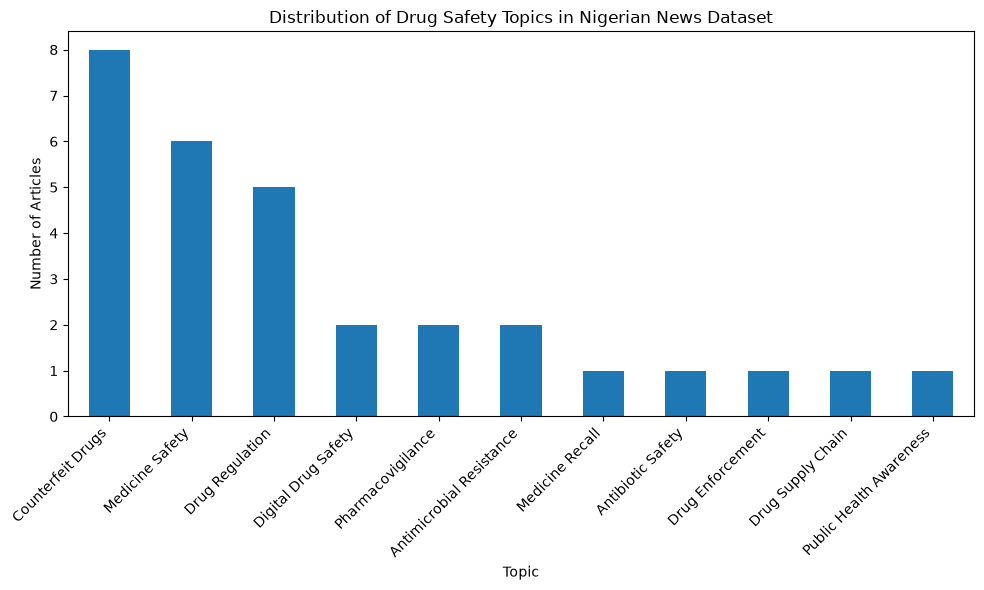

In [17]:
import matplotlib.pyplot as plt

topic_counts = df['topic_keyword'].value_counts()

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')

plt.title('Distribution of Drug Safety Topics in Nigerian News Dataset')
plt.xlabel('Topic')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

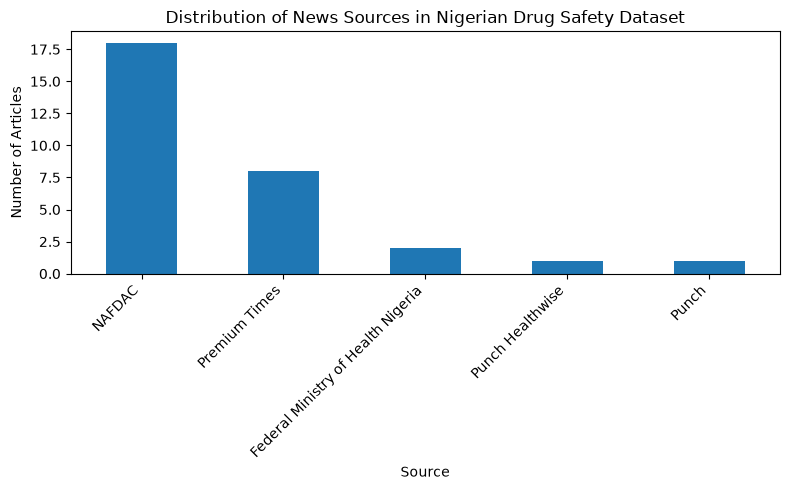

In [19]:
source_counts = df['source'].value_counts()

plt.figure(figsize=(8, 5))
source_counts.plot(kind='bar')

plt.title('Distribution of News Sources in Nigerian Drug Safety Dataset')
plt.xlabel('Source')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("topic_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

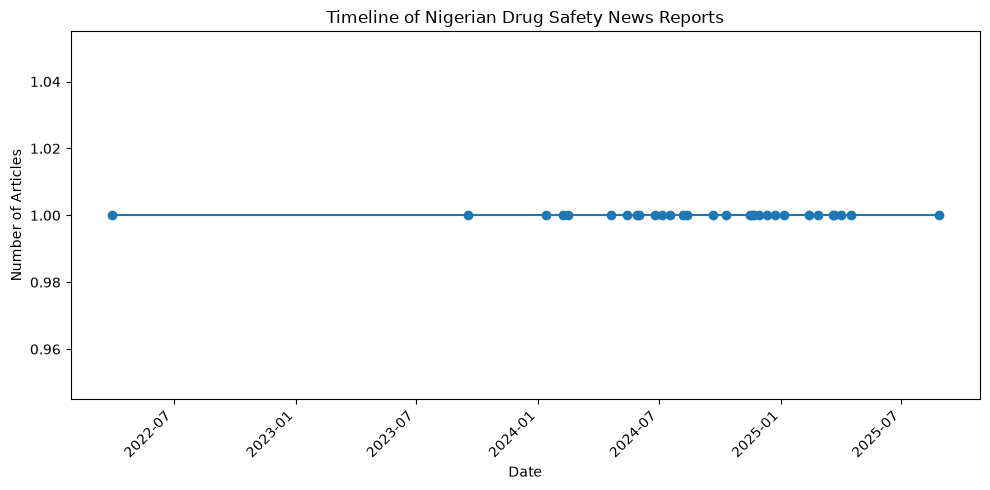

In [19]:
date_counts = df['date'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
date_counts.plot(kind='line', marker='o')

plt.title('Timeline of Nigerian Drug Safety News Reports')
plt.xlabel('Date')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [20]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,NAFDAC warned Nigerians about an unregistered ...,nafdac warned nigerians about an unregistered ...
1,NAFDAC alerted the public about counterfeit Ar...,nafdac alerted the public about counterfeit ar...
2,NAFDAC promoted digital tools including GreenB...,nafdac promoted digital tools including greenb...
3,NAFDAC warned healthcare workers and patients ...,nafdac warned healthcare workers and patients ...
4,NAFDAC reported mislabelled injections circula...,nafdac reported mislabelled injections circula...


In [21]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

df[['clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AGV\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,clean_text
0,nafdac warned nigerians unregistered ceftriaxo...
1,nafdac alerted public counterfeit artemetherlu...
2,nafdac promoted digital tools including greenb...
3,nafdac warned healthcare workers patients coun...
4,nafdac reported mislabelled injections circula...


In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/NDSNC_raw_articles.csv")

In [2]:
df['date'] = pd.to_datetime(df['date'])

In [3]:
df['topic_keyword'] = df['topic_keyword'].str.strip()

In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [5]:
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [6]:
df.shape

(30, 7)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)

tfidf_matrix = vectorizer.fit_transform(df['clean_text'])

tfidf_matrix.shape

(30, 100)

In [8]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda_topics = lda_model.fit_transform(tfidf_matrix)

lda_topics.shape

(30, 5)

In [9]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda_topics = lda_model.fit_transform(tfidf_matrix)

lda_topics.shape

(30, 5)

In [10]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx + 1}:")
    top_words = topic.argsort()[-10:][::-1]
    print([feature_names[i] for i in top_words])


Topic 1:
['activities', 'pharmacovigilance', 'nafdac', 'medicines', 'reported', 'prevent', 'entering', 'consumers', 'medicine', 'unregistered']

Topic 2:
['nigeria', 'professionals', 'circulating', 'injection', 'nafdac', 'approved', 'nigerians', 'warned', 'healthcare', 'resistance']

Topic 3:
['alerted', 'nafdac', 'falsified', 'medicines', 'public', 'improve', 'products', 'seized', 'medicine', 'advised']

Topic 4:
['nigerians', 'advised', 'medicines', 'providers', 'counterfeit', 'antibiotic', 'discovered', 'use', 'surveillance', 'nafdac']

Topic 5:
['counterfeit', 'pharmaceutical', 'warned', 'published', 'products', 'batches', 'showing', 'testing', 'treatment', 'nigeria']


In [11]:
df['lda_topic'] = lda_topics.argmax(axis=1)

df[['title', 'lda_topic']].head(10)

,title,lda_topic
0,Public Alert No. 09/2024 – Sale of Unregistere...,3
1,NAFDAC exposes new counterfeit drugs circulati...,2
2,NAFDAC introduces new technology to combat cou...,0
3,NAFDAC alerts Nigerians on fake cancer treatme...,4
4,NAFDAC alerts public on counterfeit chlorpheni...,2
5,NAFDAC destroys fake drugs worth N100trn,2
6,Fake Drugs: NAFDAC takes over Ariaria drug mar...,0
7,NAFDAC warns against circulation of falsified ...,2
8,NAFDAC warns of counterfeit Avastin cancer dru...,3
9,NAFDAC recalls multiple substandard and falsif...,4


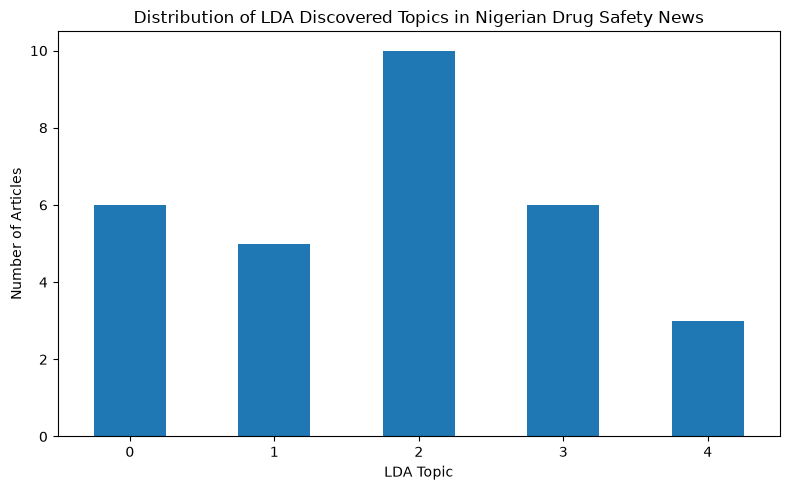

In [20]:
import matplotlib.pyplot as plt
lda_counts = df['lda_topic'].value_counts().sort_index()

plt.figure(figsize=(8,5))

lda_counts.plot(kind='bar')

plt.title('Distribution of LDA Discovered Topics in Nigerian Drug Safety News')
plt.xlabel('LDA Topic')
plt.ylabel('Number of Articles')

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("topic_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

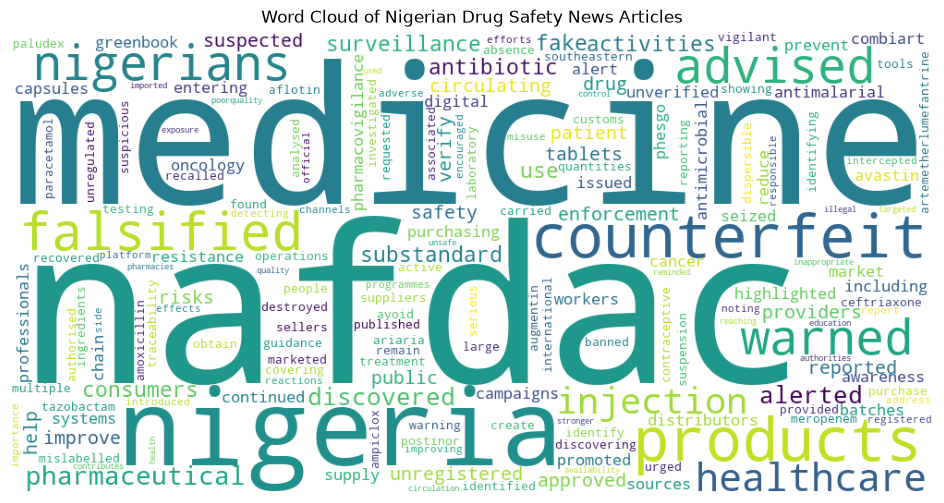

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Word Cloud of Nigerian Drug Safety News Articles')

plt.savefig("topic_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
id="9k3x8v"
topic_summary = df[['title', 'topic_keyword', 'lda_topic']]

topic_summary.head(10)

,title,topic_keyword,lda_topic
0,Public Alert No. 09/2024 – Sale of Unregistere...,Counterfeit Drugs,3
1,NAFDAC exposes new counterfeit drugs circulati...,Counterfeit Drugs,2
2,NAFDAC introduces new technology to combat cou...,Digital Drug Safety,0
3,NAFDAC alerts Nigerians on fake cancer treatme...,Counterfeit Drugs,4
4,NAFDAC alerts public on counterfeit chlorpheni...,Medicine Safety,2
5,NAFDAC destroys fake drugs worth N100trn,Drug Regulation,2
6,Fake Drugs: NAFDAC takes over Ariaria drug mar...,Drug Regulation,0
7,NAFDAC warns against circulation of falsified ...,Counterfeit Drugs,2
8,NAFDAC warns of counterfeit Avastin cancer dru...,Medicine Safety,3
9,NAFDAC recalls multiple substandard and falsif...,Medicine Recall,4


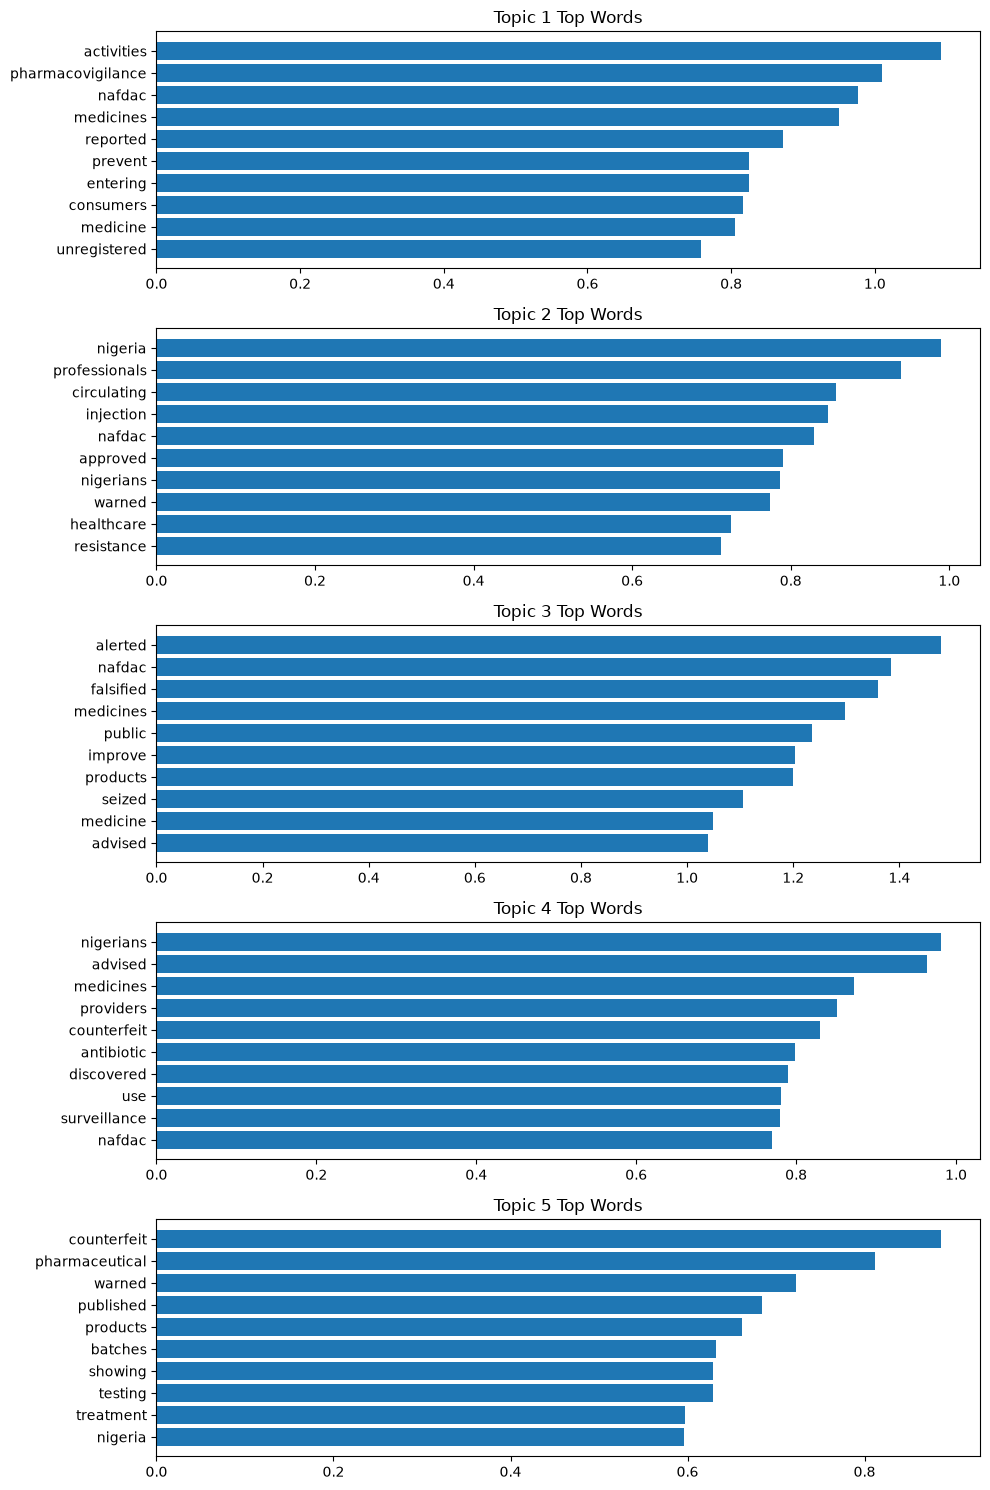

In [22]:
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(5, 1, figsize=(10, 15))

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = topic.argsort()[-10:]
    words = [feature_names[i] for i in top_words]
    weights = [topic[i] for i in top_words]

    axes[topic_idx].barh(words, weights)
    axes[topic_idx].set_title(f"Topic {topic_idx + 1} Top Words")

plt.tight_layout()

plt.savefig("topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
summary = {
    "Total Articles Analyzed": len(df),
    "Number of Sources": df['source'].nunique(),
    "Number of Topics": df['topic_keyword'].nunique(),
    "Most Common Source": df['source'].value_counts().idxmax(),
    "Most Common Topic": df['topic_keyword'].value_counts().idxmax()
}

summary

{'Total Articles Analyzed': 30,
 'Number of Sources': 5,
 'Number of Topics': 11,
 'Most Common Source': 'NAFDAC',
 'Most Common Topic': 'Counterfeit Drugs'}

# Key Findings and Conclusion

## Key Findings

The analysis of Nigerian drug safety news revealed several important patterns:

- Counterfeit and falsified medicines were the dominant concerns reported across the dataset.
- NAFDAC was the most frequently represented source, reflecting its major role in medicine regulation and public alerts.
- Other major themes included medicine safety, drug regulation, pharmacovigilance, antimicrobial resistance, and digital drug safety.
- The LDA topic modelling approach successfully identified hidden themes within the news articles and showed meaningful overlap with manually assigned categories.
- Word frequency analysis highlighted important terms including counterfeit, medicines, NAFDAC, products, healthcare providers, and safety.

## Conclusion

This project demonstrates the application of Natural Language Processing techniques for analyzing public health information from Nigerian drug safety news sources.

By combining text preprocessing, TF-IDF feature extraction, and LDA topic modelling, the project provides insights into medicine safety challenges and regulatory trends.

The findings show that NLP can support monitoring of pharmaceutical risks, identification of emerging concerns, and improved understanding of public health information.